## Paper

In [1]:
from matplotlib import pyplot as plt
import numpy as np

from predhpc import paper
from predhpc.util import plot_util

%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
paper.initialize_paper_parameters(gen_dir="..", notebook=True)
ALL_FIGURES = dict()

### Fig. 1: Background

Figure saved to /home/cgillon/homedir/predhpc/results/paper/1B.png  & .svg


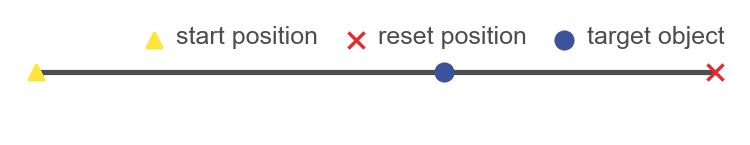

In [4]:
fig, panel = 1, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/1D.png  & .svg


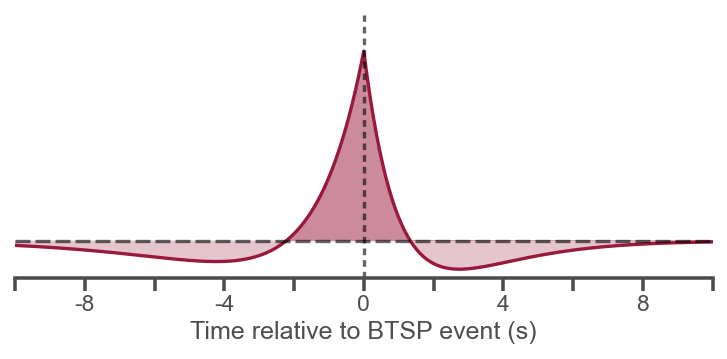

In [5]:
fig, panel = 1, "D"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(fig=fig, panel=panel)

### Fig. 2: Linear track
BTSP event recorded at step 513 and applied at step 1207.

In [6]:
linear_learner = paper.run_linear(max_time_min=1.8)

 17%|██████▌                                | 611/3600 [00:00<00:03, 752.48it/s]

BTSP event recorded at step 513 (15.39 sec).


 36%|█████████████▌                        | 1288/3600 [00:01<00:03, 722.06it/s]

BTSP update applied at step 1207 (36.21 sec).


100%|██████████████████████████████████████| 3600/3600 [00:05<00:00, 705.25it/s]


Finishing last trajectory.


1131it [00:01, 681.39it/s]

Only reached target 4 times (target: 10).
Trajectory lengths (5) to date: 28.39 +/- 15.36 sec each
Trajectory lengths (5) to date: 946.40 +/- 511.95 steps each
1 BTSP event triggered (allowed from steps 0 to 4731): occurred at step 513.


Figure saved to /home/cgillon/homedir/predhpc/results/paper/2A.png  & .svg


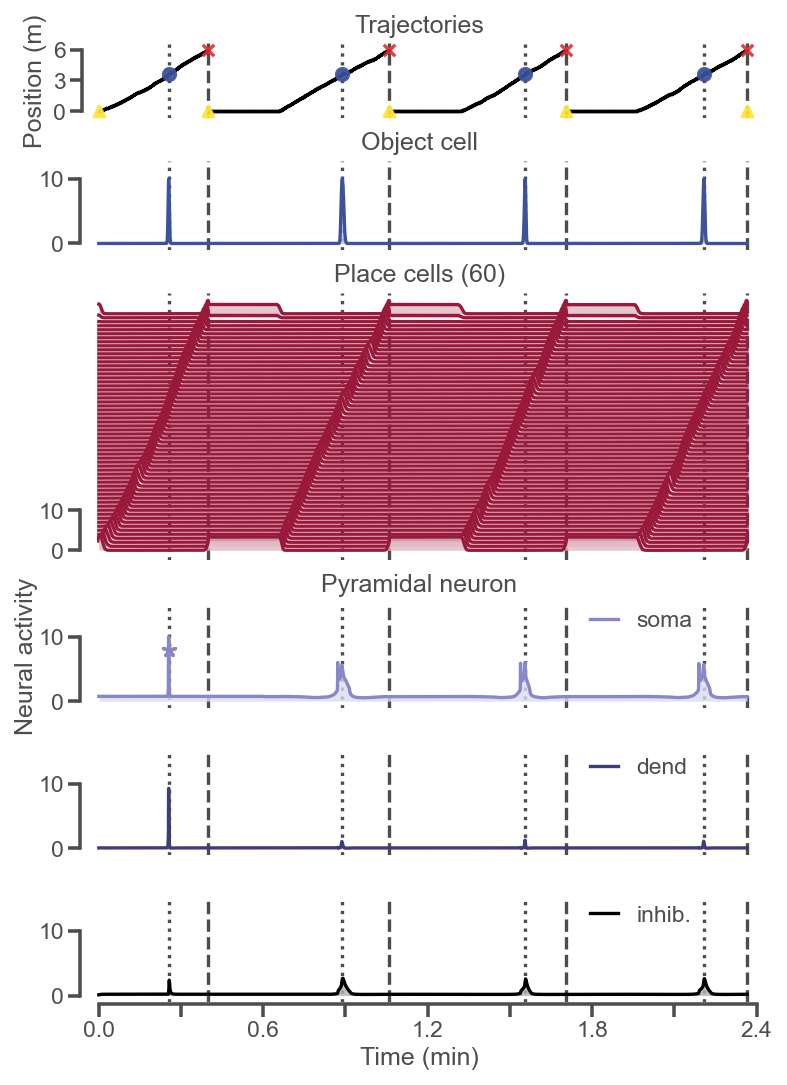

In [7]:
fig, panel = 2, "A"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/2B.png  & .svg


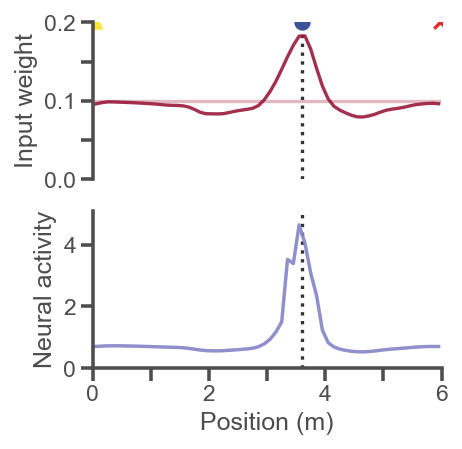

In [8]:
fig, panel = 2, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/2C.png  & .svg


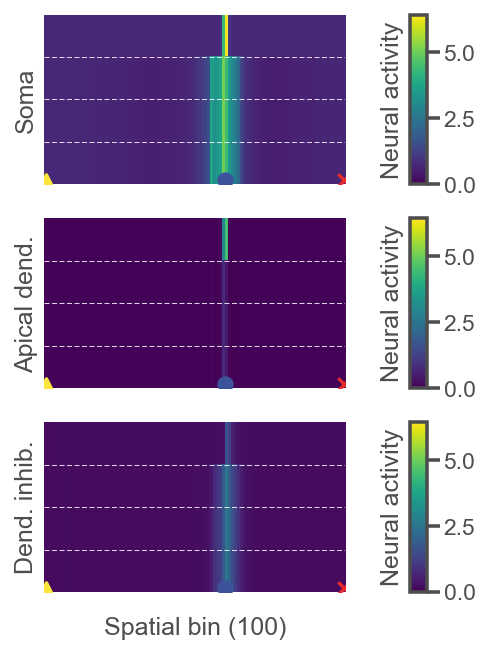

In [9]:
fig, panel = 2, "C"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

### Fig. 3: Speed and PF width
Very fast with multiple cores, but around 10 min sequentially.  

In [10]:
speed_data = paper.run_linear_fct("linear_speeds", overwrite=True, num_jobs=30)

Running...


100%|███████████████████████████████████████████| 29/29 [00:00<00:00, 46.76it/s]


Saving data to ../results/paper/speed_data_18.npz.
Time elapsed: 34.54 s.


Figure saved to /home/cgillon/homedir/predhpc/results/paper/3A.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/3A.png  & .svg


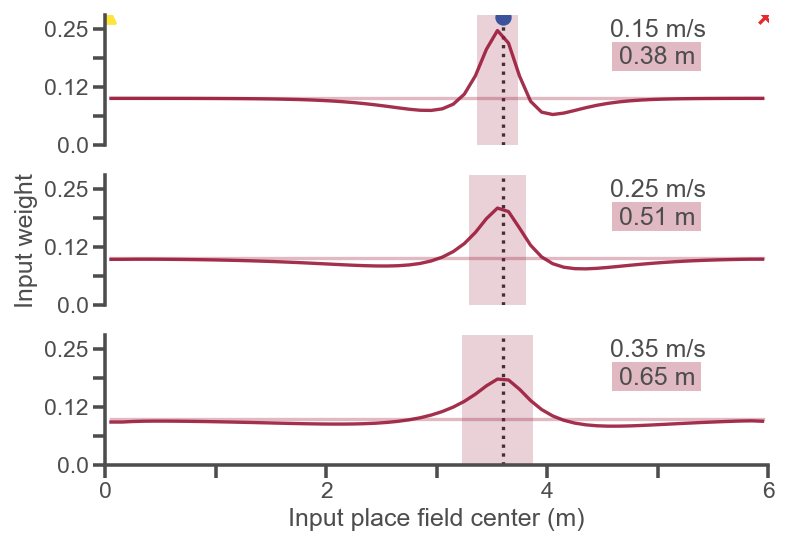

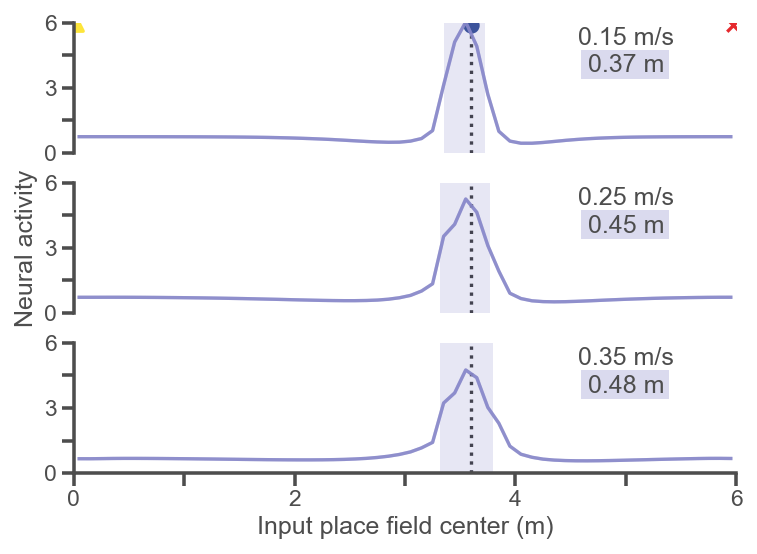

In [13]:
fig, panel = 3, "A"
for PF_type in ["weights", "history"]:
    ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(speed_data, fig=fig, panel=panel, PF_type=PF_type)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/3B.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/3B.png  & .svg


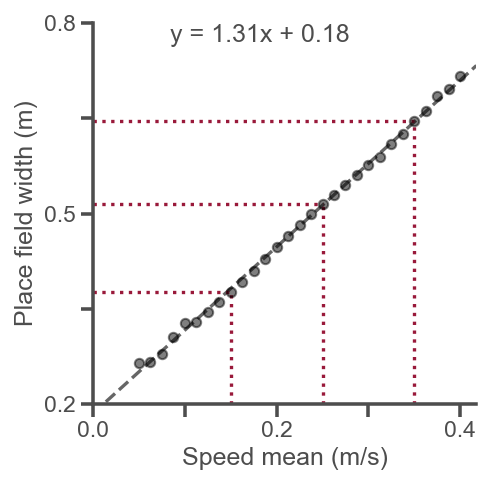

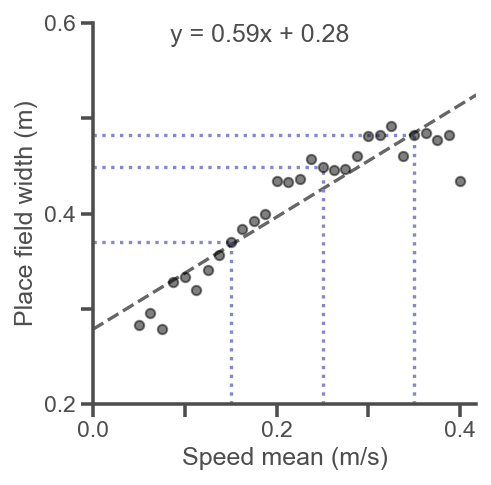

In [20]:
fig, panel = 3, "B"
for PF_type in ["weights", "history"]:
    ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(speed_data, fig=fig, panel=panel, PF_type=PF_type)

## Supplemental with graphs for 3 metric comparisons:
- input weights
- smoothed weights (a bit like VM)
- firing rate

Investigate behaviour above 0.45 m/s  
Make note in caption that trend changes at those speeds in the model. 

## Supplemental with variability in running velocity
Since running velocity during any of the period covered by the BTSP kernel affects the shape, this could be useful as well. So introduce some repeats and some level of variability. Then plot based on speed at the plateau moment, perhaps?

### Fig. 4: Effect of linear shifts
Takes about 5 min to rerun.

In [25]:
shift_data = paper.run_linear_fct("linear_shifts", overwrite=True, num_jobs=30)

Running...



100%|███████████████████████████████████████████| 61/61 [00:31<00:00,  1.93it/s]


Saving data to ../results/paper/shift_data_18.npz.
Time elapsed: 3m 3.82s.


In [44]:
%debug

> /home/cgillon/miniforge3/envs/hpc/lib/python3.11/site-packages/numpy/lib/function_base.py(1418)diff()
   1416     nd = a.ndim
   1417     if nd == 0:
-> 1418         raise ValueError("diff requires input that is at least one dimensional")
   1419     axis = normalize_axis_index(axis, nd)
   1420 



ipdb>  up


> /home/cgillon/homedir/predhpc/predhpc/util/plot_util.py(1305)get_greater_condition_for_fill_between()
   1303     condition = diff > 0
   1304 
-> 1305     change_idxs = np.where(np.diff(diff >= 0))[0]
   1306     for change_idx in change_idxs:
   1307         if condition[change_idx] and np.abs(diff[change_idx]) >= np.abs(



ipdb>  up


> /home/cgillon/homedir/predhpc/predhpc/paper_plot_fcts.py(262)plot_1D_PF_weights()
    260         for i, color in enumerate([PC_color, "royalblue"]):
    261             diff = -diff if i == 1 else diff
--> 262             cond = plot_util.get_greater_condition_for_fill_between(diff)
    263             sub_ax.fill_between(
    264                 PC_centers,



...

ipdb>  shift_data["PC_weights"].shape


(4, 1, 60)


ipdb>  PFs.shape


(60,)


ipdb>  exit


ValueError: diff requires input that is at least one dimensional

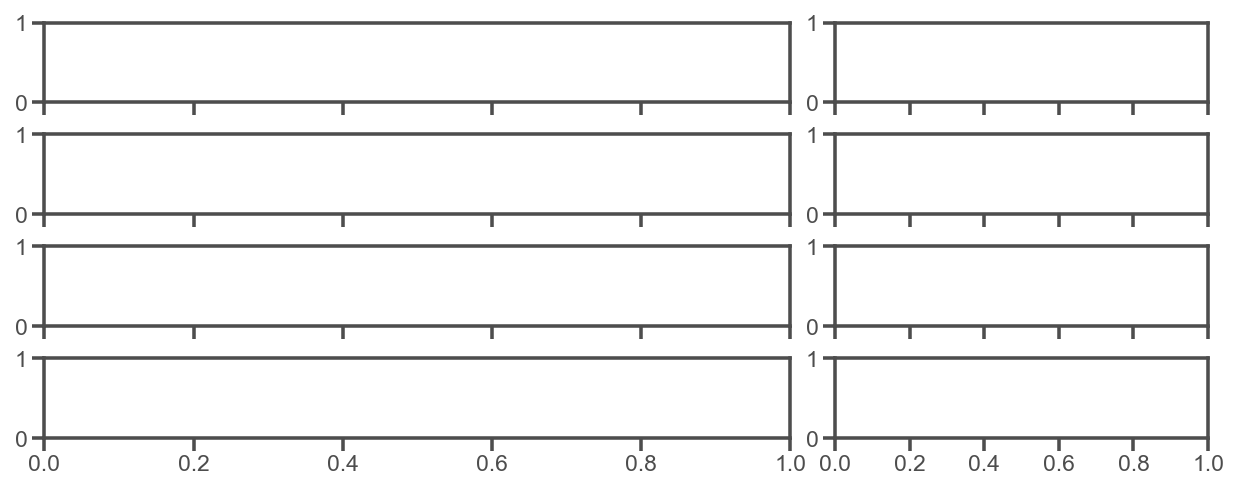

In [43]:
fig, panel = 4, "A"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(shift_data, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/4B.png  & .svg


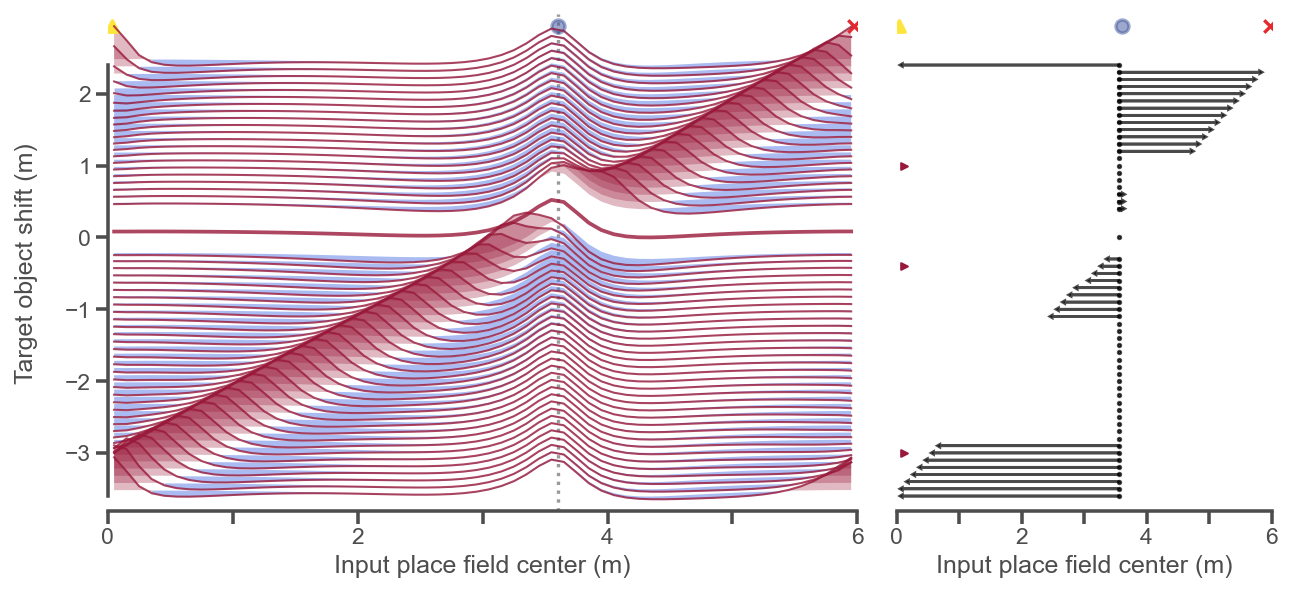

In [15]:
fig, panel = 4, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(shift_data, fig=fig, panel=panel)

### Fig. 5: 2D environment and teleportation
BTSP event recorded at step 1095 and applied at step 1789.

In [16]:
learner = paper.run_openfield_corridor()

  8%|██▊                                  | 1148/15000 [00:03<00:46, 297.21it/s]

BTSP event recorded at step 1095 (32.85 sec).


 12%|████▌                                | 1838/15000 [00:06<00:42, 308.14it/s]

BTSP update applied at step 1789 (53.67 sec).


100%|████████████████████████████████████| 15000/15000 [00:44<00:00, 334.17it/s]

Reached target 27 times.
Trajectory lengths (8) to date: 56.25 +/- 9.92 sec each
Trajectory lengths (8) to date: 1875.00 +/- 330.72 steps each
1 BTSP event triggered (allowed from steps 0 to 14999): occurred at step 1095.


Figure saved to /home/cgillon/homedir/predhpc/results/paper/5A-D.png  & .svg


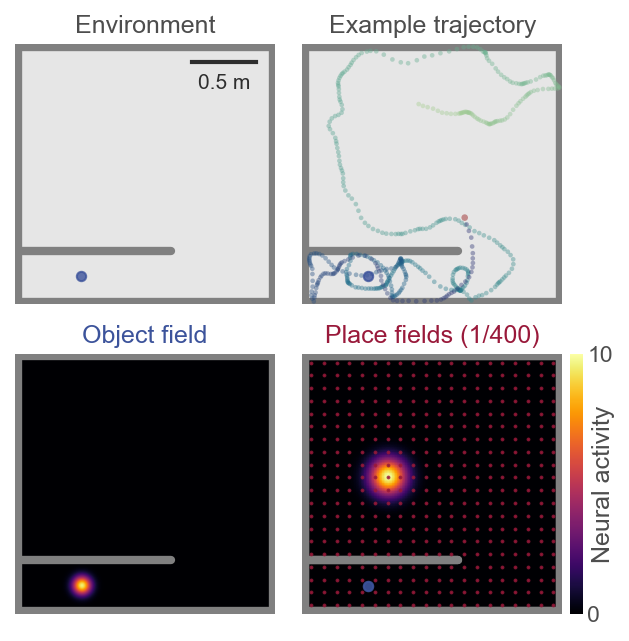

In [17]:
fig, panel = 5, "A-D"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/5E.png  & .svg


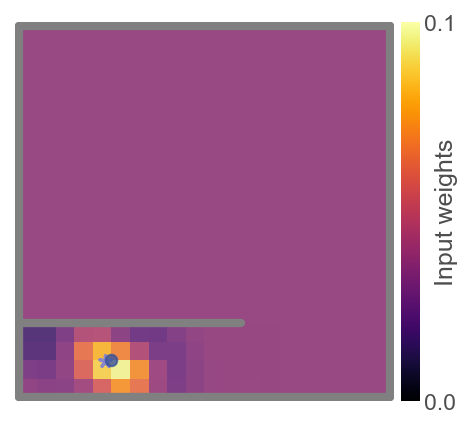

In [41]:
fig, panel = 5, "E"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/5F.png  & .svg


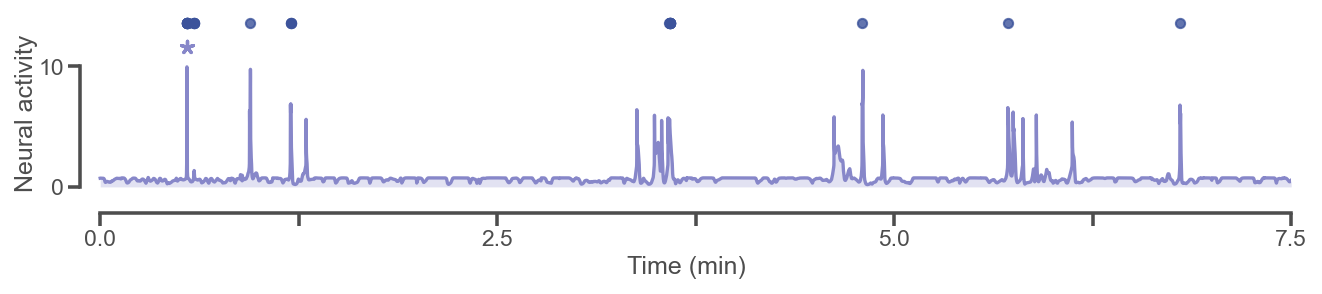

In [40]:
fig, panel = 5, "F"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel)

### Fig. 6: Teleportation

A: Teleportation ports  
B: Teleportation trajectory  
C: Remapped place field

### Fig. 7: Multiple targets

A: environment with multiple objects  
B: object fields  
C: trajectory examples  
D: 5 examples PFs  
E: all place fields overlaid  
F: BTSP events  
G: relationship between visits and number of BTSP events  

### Fig. 8: Remapping

A: remapping  
B: remapped  
C: correlation pre post

### Save figures

In [ ]:
SAVE = True

In [ ]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        fig = ax.ravel()[0].figure if isinstance(ax, np.ndarray) else ax.figure
        plot_util.save_figure(fig, key, no_timestamp=True)